In [25]:
# Cell 1: Import necessary libraries
import re
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [27]:
# Cell 2: Data Preprocessing Functions
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove timestamps and phone numbers at the start of messages
    text = re.sub(r'\[\d+/\d+/\d+\s+\d+:\d+\s+[ap]m\]\s+\+92\s+\d+\s+\d+:', '', text)

    # Remove special characters and extra whitespace
    text = re.sub(r'[^\w\s.]', '', text)
    text = ' '.join(text.split())

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)


In [28]:
# Cell 3: Feature Extraction Functions
def extract_features(job_text):
    features = {
        'code': None,
        'title': None,
        'description': None,
        'budget': None,
        'salary_type': None,
        'contact': [],
        'portfolio_demanded': False,
        'deadline': None
    }

    # Extract code
    code_match = re.search(r'code\s+(\d+)', job_text.lower())
    if code_match:
        features['code'] = code_match.group(1)

    # Extract contact numbers
    contacts = re.findall(r'\+?\d{10,12}|\d{11}', job_text)
    features['contact'] = contacts

    # Extract budget/salary
    budget_match = re.search(r'(budget|salary)\s*[:is\s]*(negotiable|\d+\.?\d*\s*[kK]?|low\s+budget)', job_text.lower())
    if budget_match:
        features['budget'] = budget_match.group(2)
        if 'k' in features['budget'].lower():
            features['salary_type'] = 'fixed'
        elif 'negotiable' in features['budget'].lower():
            features['salary_type'] = 'negotiable'
        elif 'low budget' in features['budget'].lower():
            features['salary_type'] = 'low'

    # Check if portfolio is demanded
    if any(word in job_text.lower() for word in ['portfolio', 'previous work', 'experience']):
        features['portfolio_demanded'] = True

    # Extract deadline
    deadline_match = re.search(r'deadline\s*[:\s]*(.*?(?=\n|$))', job_text.lower())
    if deadline_match:
        features['deadline'] = deadline_match.group(1).strip()

    # Extract description (text after code and before specific fields)
    desc_start = job_text.find('\n', job_text.find('Code')) + 1
    features['description'] = job_text[desc_start:].strip()

    # Attempt to extract title from first line of description
    first_line = features['description'].split('\n')[0].strip()
    if len(first_line.split()) <= 10:  # Assuming title is short
        features['title'] = first_line

    return features


In [39]:
# Cell 4: Load and Process Data
file_path = 'all-jobs.txt'

try:
    with open(file_path, 'r', encoding='utf-8') as file:
        sample_data = file.read()
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found. Please upload the file to Colab.")
    sample_data = ""  # Fallback empty string

# Split into individual job postings
job_postings = re.split(r'(?=Code\s+\d+)', sample_data)[1:]  # Split on Code but keep it
job_postings = ['Code ' + post.strip() for post in job_postings]

# Extract features and preprocess
processed_data = []
for job in job_postings:
    features = extract_features(job)
    if features['description']:  # Ensure there's content to preprocess
        features['preprocessed_text'] = preprocess_text(features['description'])
    else:
        features['preprocessed_text'] = ""
    processed_data.append(features)

# Create DataFrame
df = pd.DataFrame(processed_data)
display(df)

,code,title,description,budget,salary_type,contact,portfolio_demanded,deadline,preprocessed_text
0,964,Need Someone to make me a professional Cv,Need Someone to make me a professional Cv \nBu...,200,None,[03208871122],False,tommorow till 8 pm,need someone make professional cv budget200300...
1,966,None,Need someone to make wordle game in c++ using ...,None,None,[03328407750],False,"5th december, 8 pm",need someone make wordle game c using sfml oop...
2,967,Job Title: Microeconomics Assignment Expert,Job Title: Microeconomics Assignment Expert\nD...,None,None,[],False,8th december 2024 (sunday) 11:30pm,job title microeconomics assignment expert dea...
3,968,None,Need someone to do a simple OOP assignment in ...,None,None,[03345130822],False,is strict. need it within 10 hours,need someone simple oop assignment c. deadline...
4,969,None,There is an engineering analysis - CFD task th...,None,None,[03068045655],False,None,engineering analysis cfd task need done . invo...
...,...,...,...,...,...,...,...,...,...
1770,2994,None,Need someone to recover my hacked Instagram ac...,1.5 k,fixed,[03069790669],False,None,need someone recover hacked instagram account ...
1771,2995,Need 3d video editor,Need 3d video editor \nFor add \nBudget: negot...,negotiable,negotiable,[+923275377394],False,None,need 3d video editor add budget negotiable con...
1772,2996,None,I need someone to design a website interface.i...,None,None,[03341054928],False,sunday 12pm,need someone design website interface.if anyon...
1773,2997,1. Topic is disease classification using human...,1. Topic is disease classification using human...,None,None,[],False,None,1. topic disease classification using human ga...


In [40]:
# save dataset to csv file.
df.to_csv('all-jobs-csv.csv', index=False)

In [41]:
for col in df.columns:
    print(f"Column '{col}': {df[col].isna().sum()}")
    print(f"Column {col}: {df[col].dtype}")
    print("\n")


Column 'code': 0
Column code: object


Column 'title': 784
Column title: object


Column 'description': 0
Column description: object


Column 'budget': 1120
Column budget: object


Column 'salary_type': 1287
Column salary_type: object


Column 'contact': 0
Column contact: object


Column 'portfolio_demanded': 0
Column portfolio_demanded: bool


Column 'deadline': 1357
Column deadline: object


Column 'preprocessed_text': 0
Column preprocessed_text: object




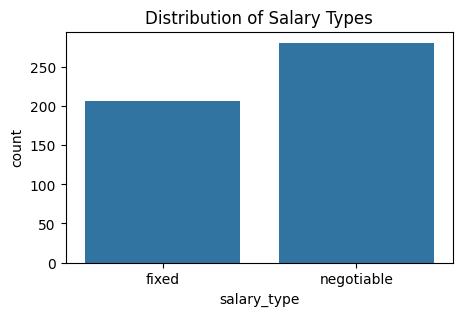

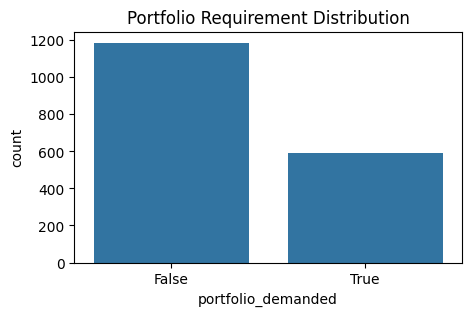

In [42]:
# Cell 5: Data Visualization
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='salary_type')
plt.title('Distribution of Salary Types')
plt.show()

print("\n\n\n")

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='portfolio_demanded')
plt.title('Portfolio Requirement Distribution')
plt.show()

In [44]:
# Cell: Data Preprocessing from CSV
import pandas as pd
import numpy as np
import re

# Function to load CSV file
def load_csv(file_path):
    try:
        df = pd.read_csv(file_path)
        print("Data loaded successfully!")
        return df
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found. Please upload the file.")
        return None
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

# Function to handle missing values
def handle_missing_values(df):
    # Define strategies for each column
    missing_strategies = {
        'code': 'fill_with_default',  # No missing, but ensure consistency
        'title': 'fill_with_unknown', # 127 missing
        'description': 'fill_with_empty',  # No missing
        'budget': 'fill_with_unknown',  # 175 missing
        'salary_type': 'fill_with_unknown',  # 198 missing
        'contact': 'fill_with_empty',  # No missing
        'portfolio_demanded': 'fill_with_false',  # No missing, bool
        'deadline': 'fill_with_unknown',  # 221 missing
        'preprocessed_text': 'fill_with_empty'  # No missing
    }

    for column, strategy in missing_strategies.items():
        if strategy == 'fill_with_default':
            df[column] = df[column].fillna(0)  # For numeric-like codes
        elif strategy == 'fill_with_unknown':
            df[column] = df[column].fillna('unknown')
        elif strategy == 'fill_with_empty':
            df[column] = df[column].fillna('')
        elif strategy == 'fill_with_false':
            df[column] = df[column].fillna(False)

    return df

# Function to convert data types
def ensure_data_types(df):
    # Expected data types
    data_types = {
        'code': str,  # Convert to string even if numeric
        'title': str,
        'description': str,
        'budget': str,
        'salary_type': str,
        'contact': str,  # Keep as string since it might contain multiple numbers
        'portfolio_demanded': bool,
        'deadline': str,
        'preprocessed_text': str
    }

    for column, dtype in data_types.items():
        if column in df.columns:
            if dtype == bool:
                # Handle potential string representations of boolean
                df[column] = df[column].apply(lambda x: True if str(x).lower() in ['true', '1', 'yes'] else False)
            else:
                # Convert to string and handle NaN/None gracefully
                df[column] = df[column].astype(str).replace('nan', '')

    return df

# Function to clean specific columns
def clean_columns(df):
    # Clean 'code': Remove any non-numeric parts if needed
    df['code'] = df['code'].apply(lambda x: re.sub(r'[^0-9]', '', str(x)))

    # Clean 'contact': Ensure it's a string of numbers, remove extra characters
    df['contact'] = df['contact'].apply(lambda x: ','.join(re.findall(r'\d{10,12}', str(x))) if x else '')

    # Clean 'budget': Standardize 'unknown', 'negotiable', etc.
    df['budget'] = df['budget'].str.lower().replace('nan', 'unknown')

    # Clean 'salary_type': Standardize values
    df['salary_type'] = df['salary_type'].str.lower().replace('nan', 'unknown')

    return df

# Main preprocessing function
def preprocess_data(file_path):
    # Load data
    df = load_csv(file_path)
    if df is None:
        return None

    # Print initial info
    print("Initial Data Info:")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Handle missing values
    df = handle_missing_values(df)

    # Ensure correct data types
    df = ensure_data_types(df)

    # Clean specific columns
    df = clean_columns(df)

    # Verify results
    print("\nAfter Preprocessing Info:")
    print(df.info())
    print("\nMissing Values After Preprocessing:")
    print(df.isnull().sum())

    return df

# Execute preprocessing
file_path = 'all-jobs-csv.csv'
processed_df = preprocess_data(file_path)

# Display the first few rows
if processed_df is not None:
    display(processed_df.head())

Data loaded successfully!
Initial Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1775 entries, 0 to 1774
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   code                1775 non-null   int64 
 1   title               991 non-null    object
 2   description         1775 non-null   object
 3   budget              655 non-null    object
 4   salary_type         488 non-null    object
 5   contact             1775 non-null   object
 6   portfolio_demanded  1775 non-null   bool  
 7   deadline            417 non-null    object
 8   preprocessed_text   1775 non-null   object
dtypes: bool(1), int64(1), object(7)
memory usage: 112.8+ KB
None

Missing Values:
code                     0
title                  784
description              0
budget                1120
salary_type           1287
contact                  0
portfolio_demanded       0
deadline              1358
preprocessed_text     

,code,title,description,budget,salary_type,contact,portfolio_demanded,deadline,preprocessed_text
0,964,Need Someone to make me a professional Cv,Need Someone to make me a professional Cv \nBu...,200,unknown,03208871122,False,tommorow till 8 pm,need someone make professional cv budget200300...
1,966,unknown,Need someone to make wordle game in c++ using ...,unknown,unknown,03328407750,False,"5th december, 8 pm",need someone make wordle game c using sfml oop...
2,967,Job Title: Microeconomics Assignment Expert,Job Title: Microeconomics Assignment Expert\nD...,unknown,unknown,,False,8th december 2024 (sunday) 11:30pm,job title microeconomics assignment expert dea...
3,968,unknown,Need someone to do a simple OOP assignment in ...,unknown,unknown,03345130822,False,is strict. need it within 10 hours,need someone simple oop assignment c. deadline...
4,969,unknown,There is an engineering analysis - CFD task th...,unknown,unknown,03068045655,False,unknown,engineering analysis cfd task need done . invo...
